In [1]:
import os
import numpy as np
import numpy.linalg as LA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

np.random.seed(0)

BASE_INPUT = "../input/nomad2018-predict-transparent-conductors"



In [2]:
train_csv = os.path.join(BASE_INPUT, "train.csv")
test_csv = os.path.join(BASE_INPUT, "test.csv")
sample_sub_csv = os.path.join(BASE_INPUT, "sample_submission.csv")

df_train = pd.read_csv(train_csv)
df_train["dataset"] = "train"
df_test = pd.read_csv(test_csv)
df_test["dataset"] = "test"

test_len = len(df_test)
df = pd.concat([df_train, df_test], axis=0, ignore_index=True, sort=False)
df_len = len(df)

print("train:", df_train.shape, "test:", df_test.shape, "all:", df.shape)



train: (2160, 15) test: (240, 13) all: (2400, 15)


In [3]:
df.head()



,id,spacegroup,number_of_total_atoms,percent_atom_al,percent_atom_ga,percent_atom_in,lattice_vector_1_ang,lattice_vector_2_ang,lattice_vector_3_ang,lattice_angle_alpha_degree,lattice_angle_beta_degree,lattice_angle_gamma_degree,formation_energy_ev_natom,bandgap_energy_ev,dataset
0,1,206,80.0,0.3125,0.6250,0.0625,9.3282,9.3279,9.3277,90.0047,90.0045,89.9950,0.1337,2.6562,train
1,2,206,80.0,1.0000,0.0000,0.0000,8.9847,8.9839,8.9843,90.0024,90.0036,89.9994,0.0738,5.2114,train
2,3,227,40.0,0.8125,0.0000,0.1875,5.8341,5.8343,14.3401,89.9999,89.9980,120.0005,0.3671,1.8353,train
3,4,12,20.0,0.2500,0.6250,0.1250,12.3144,3.0840,5.9539,89.9999,104.1046,90.0001,0.0698,2.3056,train
4,5,33,80.0,0.0000,0.1875,0.8125,11.1457,9.4822,10.1054,89.9994,89.9967,90.0000,0.1154,0.9503,train


In [4]:
df.tail()




/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,id,spacegroup,number_of_total_atoms,percent_atom_al,percent_atom_ga,percent_atom_in,lattice_vector_1_ang,lattice_vector_2_ang,lattice_vector_3_ang,lattice_angle_alpha_degree,lattice_angle_beta_degree,lattice_angle_gamma_degree,formation_energy_ev_natom,bandgap_energy_ev,dataset
2395,236,194,80.0,0.5000,0.5000,0.0000,6.2225,6.2224,23.7226,90.0187,89.9985,120.0009,NaN,NaN,test
2396,237,167,30.0,0.2500,0.5833,0.1667,5.0842,5.0838,13.6878,89.9968,90.0041,120.0005,NaN,NaN,test
2397,238,33,80.0,0.6562,0.2188,0.1250,10.0763,8.6437,9.2716,90.0034,90.0019,90.0012,NaN,NaN,test
2398,239,206,80.0,0.5625,0.4375,0.0000,9.1680,9.1675,9.1675,90.0042,90.0044,89.9963,NaN,NaN,test
2399,240,194,80.0,0.3750,0.3750,0.2500,6.4468,6.4466,24.1380,90.0128,90.0049,119.9952,NaN,NaN,test


In [5]:
def get_xyz(filename):
    xyz = []
    lattice = []
    with open(filename, "r") as f:
        lines = [ln.strip() for ln in f if ln.strip()]

    if not lines:
        return xyz, lattice

    first = lines[0].split()[0]
    is_int = False
    try:
        int(first)
        is_int = True
    except Exception:
        is_int = False

    # XYZ format:
    # line 0: number of atoms
    # line 1: comment
    # line 2+: "El x y z" (sometimes)
    if is_int and len(lines) >= 3:
        for ln in lines[2:]:
            parts = ln.split()
            if len(parts) < 4:
                continue
            sym = parts[0]
            try:
                pos = np.array(parts[1:4], dtype=float)
            except Exception:
                continue
            xyz.append((pos, sym))
        return xyz, lattice

    # NOMAD format:
    # atom x y z El
    # lattice_vector ax ay az
    for ln in lines:
        row = ln.split()
        if not row:
            continue
        if row[0] == "atom" and len(row) >= 5:
            try:
                pos = np.array(row[1:4], dtype=float)
                sym = row[4]
                xyz.append((pos, sym))
            except Exception:
                continue
        elif row[0] == "lattice_vector" and len(row) >= 4:
            try:
                lattice.append(np.array(row[1:4], dtype=float))
            except Exception:
                continue

    return xyz, lattice




In [6]:
def get_sine_matrix(xyz, lattice):
    n_atom = len(xyz)
    if n_atom == 0:
        return None

    if lattice is None or len(lattice) != 3:
        A = np.eye(3, dtype=float)
    else:
        A = np.transpose(np.array(lattice, dtype=float))  # columns are lattice vectors
        if A.shape != (3, 3):
            A = np.eye(3, dtype=float)

    # Use pseudo-inverse for robustness
    B = LA.pinv(A)

    distance_matrix = np.ones((n_atom, n_atom), dtype=float)
    eps = 1e-12

    for i in range(n_atom):
        for j in range(i):
            r_ij = np.dot(B, xyz[i][0] - xyz[j][0])
            sin_sq_r = (np.sin(np.pi * r_ij)) ** 2
            distance = LA.norm(np.dot(A, sin_sq_r))
            if not np.isfinite(distance) or distance < eps:
                distance = eps
            distance_matrix[i, j] = distance
            distance_matrix[j, i] = distance

    labels = np.array([sym for _, sym in xyz], dtype=object).reshape(-1, 1)
    for at, charge in zip(["O", "Al", "Ga", "In"], [8, 13, 31, 49]):
        labels = np.where(labels == at, float(charge), labels)

    labels = (
        pd.to_numeric(pd.Series(labels.reshape(-1)), errors="coerce")
        .fillna(0.0)
        .values.reshape(-1, 1)
    )

    charge_matrix = np.dot(labels, labels.T).astype(float)
    charge_matrix -= np.diag(np.diag(charge_matrix))
    charge_matrix += np.diag((0.5 * (labels.reshape(-1) ** 2.4))).astype(float)

    sine_matrix = charge_matrix / distance_matrix
    sine_matrix = np.nan_to_num(sine_matrix, nan=0.0, posinf=0.0, neginf=0.0)
    return sine_matrix




In [7]:
def get_eigenspectrum(matrix):
    spectrum = LA.eigvalsh(matrix)
    spectrum = np.sort(spectrum)[::-1]
    return spectrum




In [8]:
N_SPEC = 80  # keep same dimensionality as later PCA(n_components=80)

spectrum_list = []
missing_files = 0
bad_geoms = 0

for index in range(df_len):
    dataset_label = df.dataset.values[index]
    row_id = int(df.id.values[index])
    filename = os.path.join(BASE_INPUT, dataset_label, str(row_id), "geometry.xyz")

    if not os.path.exists(filename):
        missing_files += 1
        spectrum = np.zeros(N_SPEC, dtype=float)
    else:
        xyz, lattice = get_xyz(filename)
        sine_matrix = get_sine_matrix(xyz, lattice)
        if sine_matrix is None:
            bad_geoms += 1
            spectrum = np.zeros(N_SPEC, dtype=float)
        else:
            spectrum_raw = get_eigenspectrum(sine_matrix).astype(float)
            spectrum = np.zeros(N_SPEC, dtype=float)
            m = min(N_SPEC, len(spectrum_raw))
            spectrum[:m] = spectrum_raw[:m]

    spectrum_list.append(spectrum)

print(
    "Built spectra:",
    len(spectrum_list),
    "missing geometry files:",
    missing_files,
    "bad geoms:",
    bad_geoms,
)



Built spectra: 2400 missing geometry files: 0 bad geoms: 1


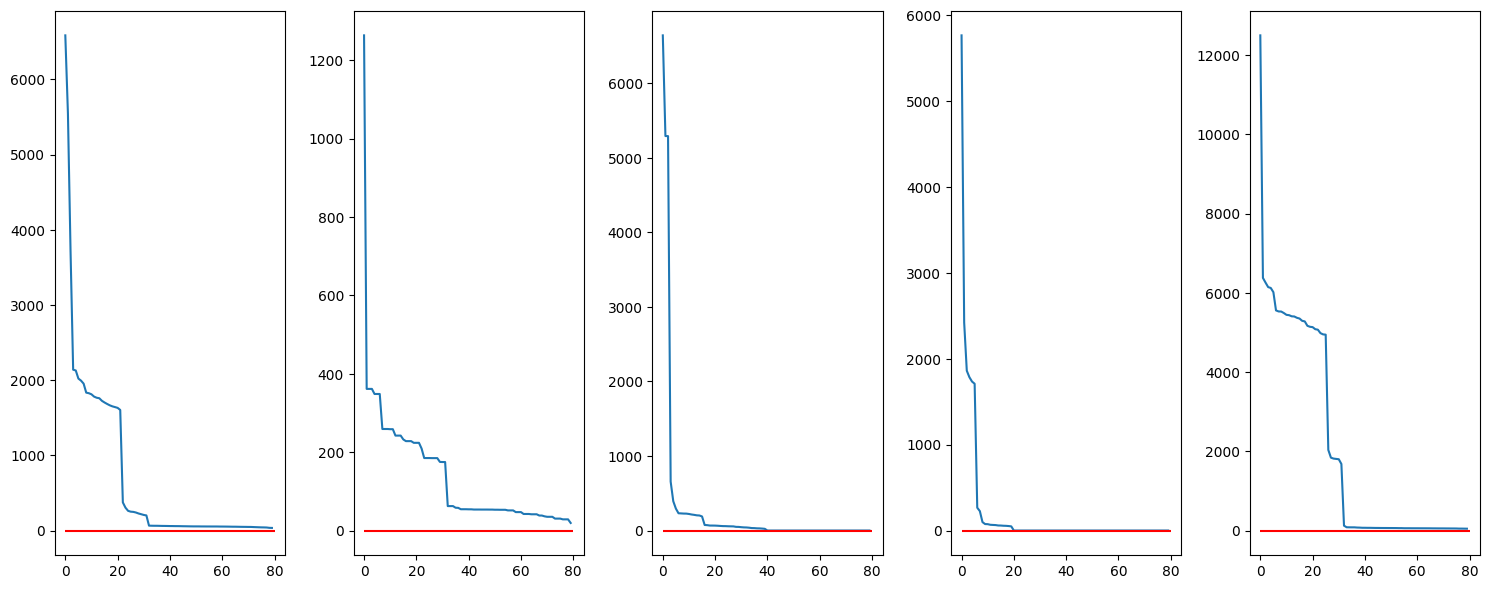

In [9]:
fig, axs = plt.subplots(1, 5, figsize=(15, 6))
for i in range(5):
    ax = axs[i]
    plot_data = spectrum_list[i]
    ax.plot(range(len(plot_data)), plot_data)
    ax.hlines(0, 0, N_SPEC, colors="r")
plt.tight_layout()
plt.show()



In [10]:
spectrum_df = pd.DataFrame(spectrum_list).astype(float)
spectrum_df = spectrum_df.fillna(0.0)

ss = StandardScaler()
spectrum_std_df = pd.DataFrame(ss.fit_transform(spectrum_df.values))

pca = PCA(n_components=N_SPEC)
spectrum_pca_df = pd.DataFrame(pca.fit_transform(spectrum_std_df.values))

spectrum_pca_df.head()



,0,1,2,3,4,5,6,7,8,9,...,70,71,72,73,74,75,76,77,78,79
0,4.290977,-3.342168,1.825793,-0.803808,-0.902897,0.076415,-0.508365,0.856961,-0.267029,-0.335469,...,-0.002521,-0.012703,-0.007069,-0.000289,0.007781,0.001327,0.009136,0.002122,0.003264,0.006049
1,0.534186,-5.803486,3.654804,1.267651,-1.025637,0.655451,0.268948,-0.627120,0.423504,0.268472,...,0.007096,0.021493,0.050820,-0.003404,-0.011723,0.003093,-0.005997,-0.008342,0.016548,0.001605
2,-8.821037,0.582834,0.800401,0.760897,-0.075182,-0.060461,-0.520332,0.886016,-0.890025,-0.905298,...,-0.001884,0.002028,-0.004077,0.005836,0.002768,0.002252,0.001141,-0.000497,0.000142,0.000872
3,-10.038860,0.527143,2.213544,-1.352517,-0.612079,-0.160412,0.895049,-0.111983,0.098636,0.159669,...,-0.000448,0.000172,0.001307,-0.000844,-0.000644,0.000667,0.000008,0.000216,0.000141,-0.000317
4,12.723067,6.856718,3.400310,0.865641,0.195799,0.162893,-0.197769,1.298142,1.706220,-1.579125,...,-0.010903,0.013627,0.004213,0.019190,-0.016664,-0.007490,-0.003696,-0.011391,0.008040,-0.008712


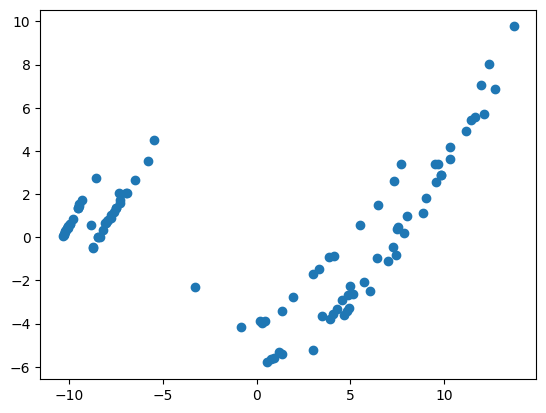

In [11]:
plt.scatter(x=spectrum_pca_df.loc[:100, 0], y=spectrum_pca_df.loc[:100, 1])
plt.show()



In [12]:
df.number_of_total_atoms = df.number_of_total_atoms.astype(int)
df["group_natoms"] = (
    df.spacegroup.astype(str) + "_" + df.number_of_total_atoms.astype(str)
)



/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


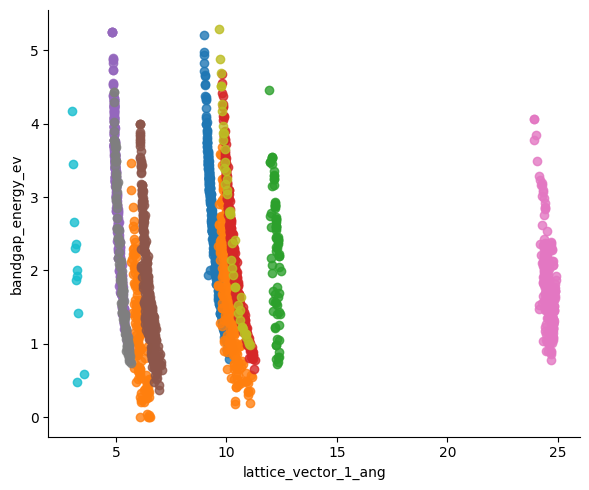

In [13]:
try:
    sns.lmplot(
        x="lattice_vector_1_ang",
        y="bandgap_energy_ev",
        hue="group_natoms",
        data=df[df["dataset"] == "train"],
        fit_reg=False,
        height=5,
        aspect=1.2,
        legend=False,
    )
    plt.show()
except Exception as e:
    print("Skipping plot:", repr(e))



In [14]:
df = df.join(pd.get_dummies(df.group_natoms))
df.drop(["group_natoms"], axis=1, inplace=True)



In [15]:
df.columns



Index(['id', 'spacegroup', 'number_of_total_atoms', 'percent_atom_al',
       'percent_atom_ga', 'percent_atom_in', 'lattice_vector_1_ang',
       'lattice_vector_2_ang', 'lattice_vector_3_ang',
       'lattice_angle_alpha_degree', 'lattice_angle_beta_degree',
       'lattice_angle_gamma_degree', 'formation_energy_ev_natom',
       'bandgap_energy_ev', 'dataset', '12_20', '12_80', '167_30', '167_60',
       '194_10', '194_80', '206_80', '227_40', '33_40', '33_80'],
      dtype='object')

In [16]:
df.drop(["dataset"], axis=1, inplace=True)
df.drop(["id", "spacegroup", "number_of_total_atoms"], axis=1, inplace=True)



In [17]:
df.columns



Index(['percent_atom_al', 'percent_atom_ga', 'percent_atom_in',
       'lattice_vector_1_ang', 'lattice_vector_2_ang', 'lattice_vector_3_ang',
       'lattice_angle_alpha_degree', 'lattice_angle_beta_degree',
       'lattice_angle_gamma_degree', 'formation_energy_ev_natom',
       'bandgap_energy_ev', '12_20', '12_80', '167_30', '167_60', '194_10',
       '194_80', '206_80', '227_40', '33_40', '33_80'],
      dtype='object')

In [18]:
df_new = pd.concat([spectrum_pca_df, df.reset_index(drop=True)], axis=1)
df_new.head()



,0,1,2,3,4,5,6,7,8,9,...,12_20,12_80,167_30,167_60,194_10,194_80,206_80,227_40,33_40,33_80
0,4.290977,-3.342168,1.825793,-0.803808,-0.902897,0.076415,-0.508365,0.856961,-0.267029,-0.335469,...,False,False,False,False,False,False,True,False,False,False
1,0.534186,-5.803486,3.654804,1.267651,-1.025637,0.655451,0.268948,-0.627120,0.423504,0.268472,...,False,False,False,False,False,False,True,False,False,False
2,-8.821037,0.582834,0.800401,0.760897,-0.075182,-0.060461,-0.520332,0.886016,-0.890025,-0.905298,...,False,False,False,False,False,False,False,True,False,False
3,-10.038860,0.527143,2.213544,-1.352517,-0.612079,-0.160412,0.895049,-0.111983,0.098636,0.159669,...,True,False,False,False,False,False,False,False,False,False
4,12.723067,6.856718,3.400310,0.865641,0.195799,0.162893,-0.197769,1.298142,1.706220,-1.579125,...,False,False,False,False,False,False,False,False,False,True


In [19]:
# Change (score-relevant correctness): only drop known-bad indices within the *training* portion
# so we never remove test rows and accidentally misalign predictions with sample_submission ids.
orig_len = len(df_new)
train_len_before_drop = orig_len - test_len

drop_idx = [
    395,
    126,
    1215,
    1886,
    2075,
    353,
    308,
    2154,
    531,
    1379,
    2319,
    2337,
    2370,
    2333,
]
drop_idx = [i for i in drop_idx if (i in df_new.index) and (i < train_len_before_drop)]

df_new.drop(drop_idx, axis=0, inplace=True)
df_new.reset_index(drop=True, inplace=True)

print(
    "After dropping rows:",
    df_new.shape,
    "dropped:",
    len(drop_idx),
    "from train portion",
)



After dropping rows: (2390, 101) dropped: 10 from train portion


In [20]:
df_new.shape



(2390, 101)

In [21]:
df_len = len(df_new)
train_len = df_len - test_len

X_all = df_new.drop(["formation_energy_ev_natom", "bandgap_energy_ev"], axis=1)
X_train = X_all.iloc[:train_len].values
X_test = X_all.iloc[train_len:].values

y_formation = df_new["formation_energy_ev_natom"].iloc[:train_len].values
y_bandgap = df_new["bandgap_energy_ev"].iloc[:train_len].values

print(
    "X_train:",
    X_train.shape,
    "X_test:",
    X_test.shape,
    "y:",
    y_formation.shape,
    y_bandgap.shape,
)



X_train: (2150, 99) X_test: (240, 99) y: (2150,) (2150,)


In [22]:
# Change (metric alignment): RMSLE is computed on log(1+y), so train models on log1p(target)
# while keeping the same model class and the same GridSearchCV procedure.
y_formation_log = np.log1p(np.clip(y_formation, 0.0, None))
y_bandgap_log = np.log1p(np.clip(y_bandgap, 0.0, None))

xgb_formation = xgb.XGBRegressor(
    random_state=0,
)
parameters = {
    "max_depth": [2, 3, 4],
    "n_estimators": [100, 200, 300],
}

cv_formation = GridSearchCV(
    xgb_formation, param_grid=parameters, cv=4, verbose=1, n_jobs=-1
)
cv_formation.fit(X_train, y_formation_log)



Fitting 4 folds for each of 9 candidates, totalling 36 fits


GridSearchCV(cv=4,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, max_bin=None,
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=0, ...),
             n_jobs=-1,
             param_grid={'max_depth': [2, 3, 4],
                         'n_estimators': [100, 200, 300]},
             verbose=1)

In [23]:
cv_formation.best_params_



{'max_depth': 2, 'n_estimators': 100}

In [24]:
xgb_bandgap = xgb.XGBRegressor(
    random_state=0,
)
parameters = {
    "max_depth": [2, 3, 4],
    "n_estimators": [100, 200, 300],
}

cv_bandgap = GridSearchCV(
    xgb_bandgap, param_grid=parameters, cv=4, verbose=1, n_jobs=-1
)
cv_bandgap.fit(X_train, y_bandgap_log)



Fitting 4 folds for each of 9 candidates, totalling 36 fits


GridSearchCV(cv=4,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, max_bin=None,
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=0, ...),
             n_jobs=-1,
             param_grid={'max_depth': [2, 3, 4],
                         'n_estimators': [100, 200, 300]},
             verbose=1)

In [25]:
cv_bandgap.best_params_




{'max_depth': 2, 'n_estimators': 100}

In [26]:
def plot_features(estimator, features):
    importances = estimator.feature_importances_
    plt.figure(figsize=(10, 15))
    plt.barh(range(len(importances)), importances, align="center")
    plt.yticks(np.arange(len(features)), features)
    plt.show()




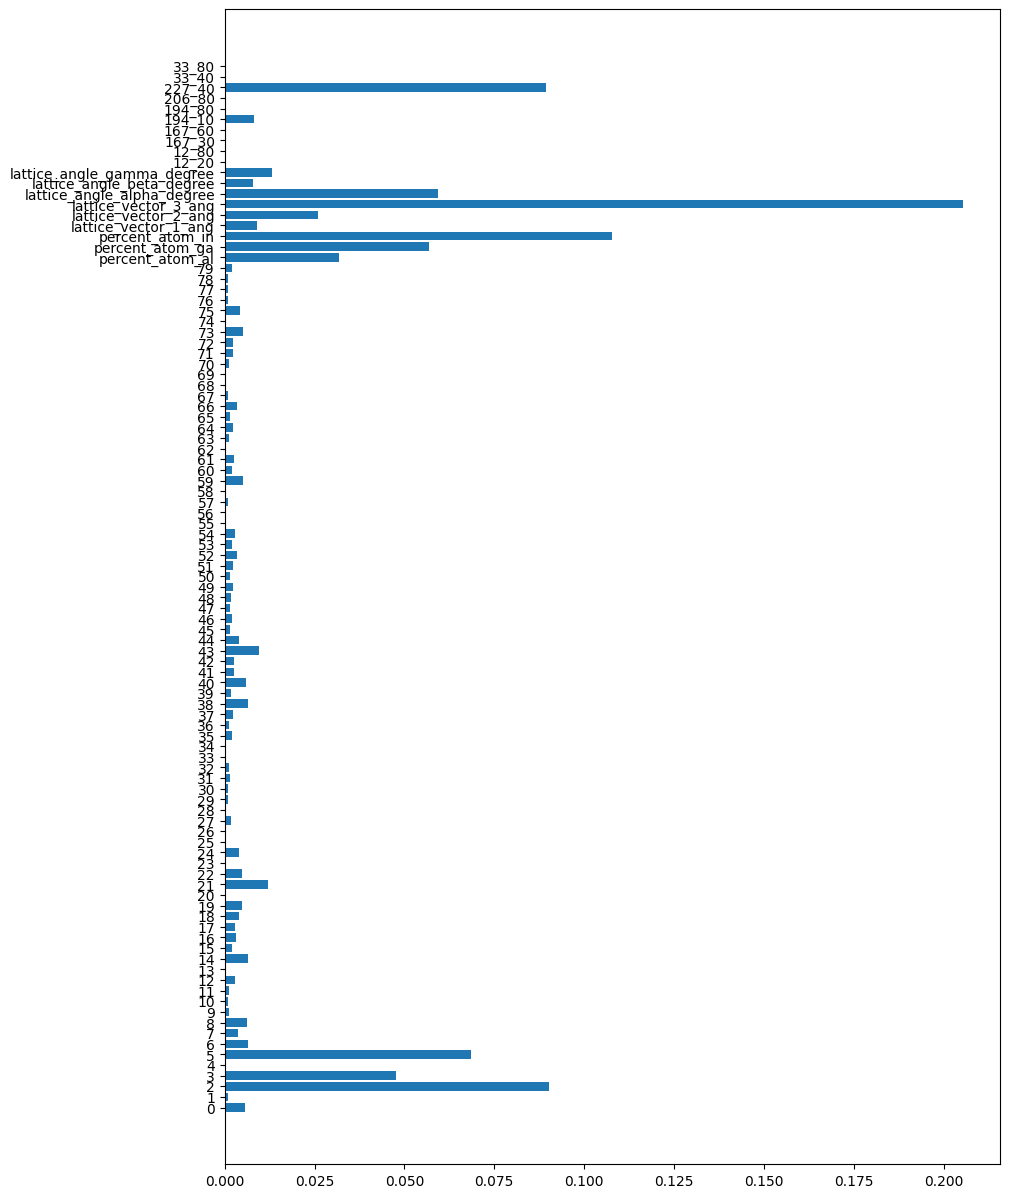

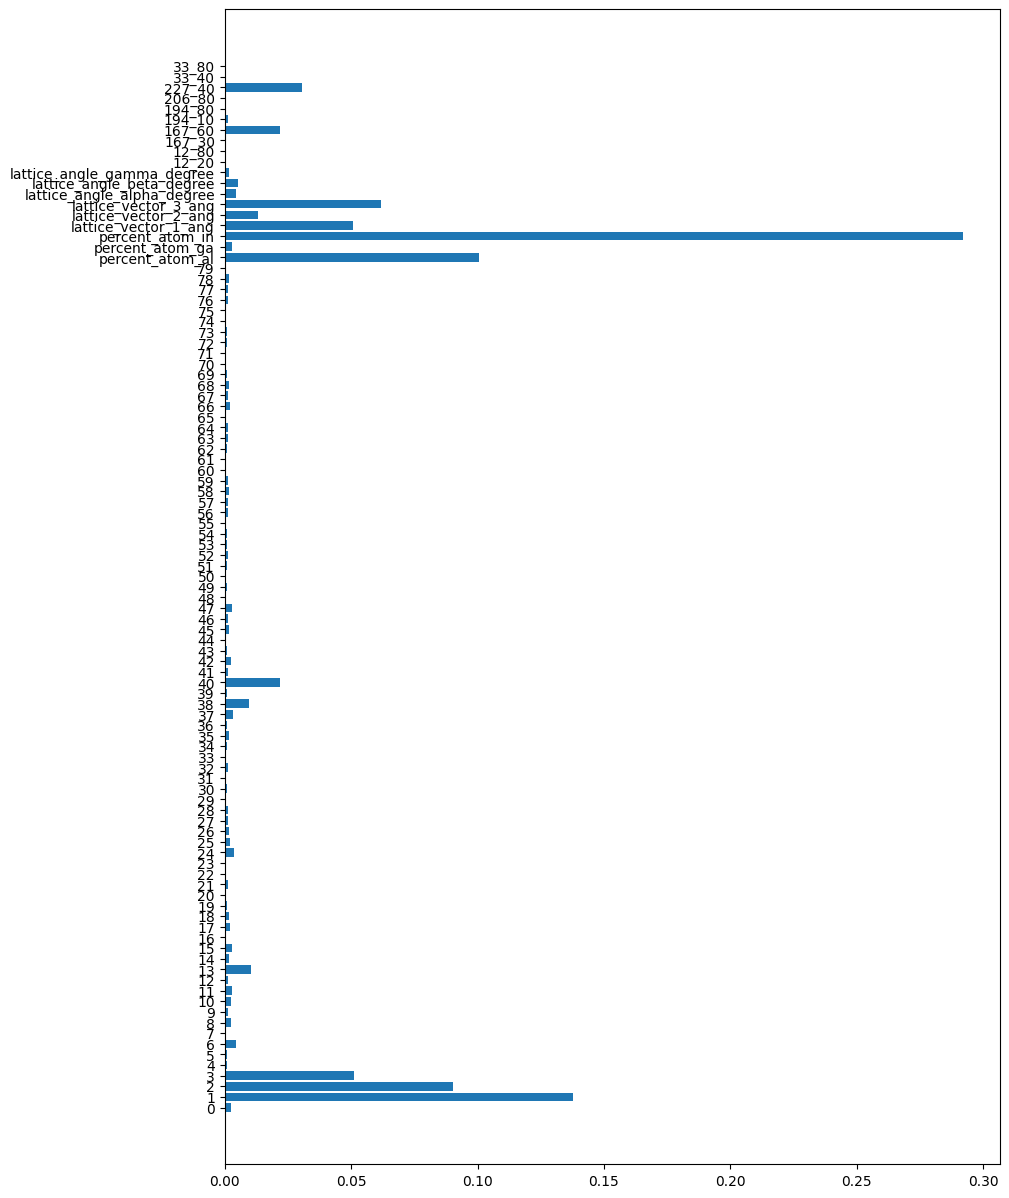

In [27]:
features = df_new.drop(
    ["formation_energy_ev_natom", "bandgap_energy_ev"], axis=1
).columns
plot_features(cv_formation.best_estimator_, features)
plot_features(cv_bandgap.best_estimator_, features)



In [28]:
# Change (metric alignment): invert the log1p transform back to original scale.
formation_pred = np.expm1(cv_formation.predict(X_test))
bandgap_pred = np.expm1(cv_bandgap.predict(X_test))

# Keep non-negative to avoid invalid RMSLE behavior.
formation_pred = np.clip(formation_pred, 0.0, None)
bandgap_pred = np.clip(bandgap_pred, 0.0, None)

print("pred shapes:", formation_pred.shape, bandgap_pred.shape)



pred shapes: (240,) (240,)


In [29]:
submission = pd.read_csv(sample_sub_csv)
submission["formation_energy_ev_natom"] = formation_pred
submission["bandgap_energy_ev"] = bandgap_pred
submission.shape



(240, 3)

In [30]:
submission.head()



,id,formation_energy_ev_natom,bandgap_energy_ev
0,1,0.225173,1.858582
1,2,0.261963,1.730054
2,3,0.102044,4.160967
3,4,0.047720,2.865241
4,5,0.370028,1.395449


In [31]:
submission.to_csv("submission.csv", index=False)
print(
    "Wrote submission.csv with columns:",
    list(submission.columns),
    "and shape:",
    submission.shape,
)

Wrote submission.csv with columns: ['id', 'formation_energy_ev_natom', 'bandgap_energy_ev'] and shape: (240, 3)
